# Business Understanding & Data Understanding — Kabupaten Bangkalan

Dokumen ini merangkum dua tahap awal analisis kualitas udara di **Kabupaten
Bangkalan, Jawa Timur**, mengikuti kerangka kerja **CRISP-DM**:
**Business Understanding** (memahami masalah dan tujuan) dan
**Data Understanding** (mengumpulkan, mengeksplorasi, dan menilai kualitas
data).

---

## 1. Business Understanding

### 1.1 Latar Belakang

Kabupaten Bangkalan terletak di ujung barat Pulau Madura dan menjadi
kabupaten yang paling terdampak langsung oleh **Jembatan Suramadu**, yang
menghubungkan Madura dengan Surabaya sejak beroperasi pada tahun 2009.
Sejak saat itu, arus kendaraan dari Surabaya yang melintas ke Madura terpusat
melalui Bangkalan, meningkatkan potensi emisi dari sektor transportasi di
wilayah ini.

Selain faktor transportasi, Bangkalan juga memiliki potensi sumber emisi
lain:
- **Pertumbuhan kawasan industri** di beberapa kecamatan yang didorong oleh
  aksesibilitas baru pasca-Suramadu.
- **Rencana fasilitas stockpile (gudang penyangga) batu bara** di pesisir
  utara (Kecamatan Klampis) untuk menopang kebutuhan industri manufaktur
  Jawa Timur — aktivitas bongkar-muat batu bara di daerah lain yang serupa
  diketahui memicu keluhan warga terkait debu dan polusi udara.
- **Aktivitas pertanian dan perikanan** yang tetap menjadi sumber emisi
  metana (CH4) skala lokal.

Kombinasi faktor transportasi, potensi industrialisasi, dan aktivitas
agraris ini menjadikan pemantauan kualitas udara di Kabupaten Bangkalan
relevan untuk dilakukan secara berkala, sebagai baseline sebelum
pembangunan lebih lanjut berlangsung.

### 1.2 Tujuan Analisis

Proyek ini bertujuan untuk:

1. **Memantau tren konsentrasi polutan udara utama** (NO2, CO, SO2, CH4) di
   Kabupaten Bangkalan sepanjang periode 24 Agustus 2025 — 24 Agustus 2026
   menggunakan data penginderaan jauh Sentinel-5P.
2. **Mengidentifikasi periode dengan konsentrasi tidak wajar (anomali/outlier)**
   yang dapat mengindikasikan kejadian tertentu (mis. lonjakan aktivitas
   transportasi, kebakaran lahan, atau gangguan pada data satelit itu
   sendiri).
3. **Menyediakan baseline data kualitas udara** yang dapat dipakai sebagai
   pembanding di masa depan, terutama seiring rencana pertumbuhan kawasan
   industri di wilayah pesisir.
4. **Menyusun alur kerja (pipeline) yang reusable** — mulai dari ekstraksi
   data satelit, pembersihan data, hingga deteksi anomali — sehingga dapat
   diterapkan kembali untuk kabupaten/kota lain atau periode waktu
   berikutnya.

### 1.3 Apa itu Indeks Kualitas Udara (AQI)?

**Indeks Kualitas Udara (Air Quality Index / AQI)** adalah standar
pengukuran untuk melaporkan seberapa bersih atau tercemarnya udara di suatu
wilayah. AQI mengubah konsentrasi polutan menjadi angka pada skala 0–500,
di mana angka lebih rendah menandakan kualitas udara lebih baik.

| Rentang AQI | Kategori | Dampak Kesehatan |
|:-----------:|:--------:|:-----------------|
| 0 – 50 | Baik | Kualitas udara memuaskan, risiko polusi rendah |
| 51 – 100 | Sedang | Kualitas udara dapat diterima |
| 101 – 150 | Tidak Sehat bagi Kelompok Sensitif | Anak, lansia, dan penderita asma mulai terdampak |
| 151 – 200 | Tidak Sehat | Seluruh populasi mulai mengalami efek kesehatan |
| 201 – 300 | Sangat Tidak Sehat | Peringatan kesehatan untuk seluruh populasi |
| 301 – 500 | Berbahaya | Kondisi darurat kesehatan masyarakat |

### 1.4 Polutan yang Dianalisis

#### a. NO2 (Nitrogen Dioksida)

Gas berwarna coklat kemerahan dengan bau menyengat. Sumber utama:
- Emisi kendaraan bermotor (pembakaran bahan bakar fosil).
- Aktivitas industri berbasis pembakaran.
- Pembangkit listrik berbahan bakar fosil.

**Dampak kesehatan:** iritasi saluran pernapasan, meningkatkan risiko
infeksi pernapasan, memperburuk asma. Di Bangkalan, NO2 relevan dipantau
karena kepadatan lalu lintas di sekitar akses Suramadu.

#### b. CO (Karbon Monoksida)

Gas tidak berwarna dan tidak berbau, sangat berbahaya. Sumber utama:
- Pembakaran tidak sempurna bahan bakar kendaraan.
- Asap industri manufaktur.
- Pembakaran biomassa (sampah, kayu bakar).

**Dampak kesehatan:** mengikat hemoglobin lebih kuat dari oksigen sehingga
menyebabkan kekurangan oksigen pada organ tubuh, pusing, mual, dan pada
paparan tinggi dapat menyebabkan kematian.

#### c. SO2 (Sulfur Dioksida)

Gas tak berwarna dengan bau tajam. Sumber utama:
- Pembakaran batu bara pada industri dan pembangkit listrik.
- Proses industri seperti peleburan logam dan pemurnian minyak bumi.
- Emisi kendaraan berbahan bakar tinggi sulfur.

**Dampak kesehatan:** iritasi mata dan tenggorokan, memperburuk asma dan
bronkitis, serta berkontribusi pada hujan asam. Polutan ini penting
dipantau di Bangkalan mengingat rencana aktivitas bongkar-muat batu bara di
pesisir utara.

#### d. CH4 (Metana)

Gas rumah kaca yang sangat efektif memerangkap panas. Sumber utama:
- Aktivitas pertanian — pencernaan hewan ternak dan sawah.
- Limbah organik — pembusukan sampah di TPA.
- Emisi industri — kebocoran gas alam dan proses industri.

**Dampak lingkungan:** CH4 sekitar **80 kali lebih kuat** dari CO2 dalam
memerangkap panas jangka pendek, sehingga berkontribusi signifikan pada
perubahan iklim.

### 1.5 Ruang Lingkup

- **Wilayah:** Kabupaten Bangkalan, Jawa Timur (bounding box, lihat Bagian 2.3).
- **Polutan:** NO2, CO, SO2, CH4.
- **Periode:** 24 Agustus 2025 — 24 Agustus 2026 (deret waktu harian).
- **Sumber data:** Sentinel-5P L2 (TROPOMI) via Copernicus Data Space Ecosystem.
- **Keluaran:** deret waktu harian per polutan, visualisasi tren, dan daftar
  tanggal dengan anomali/outlier terdeteksi.

---

## 2. Data Understanding

Data Understanding adalah tahap untuk **mengumpulkan**, **mengeksplorasi**,
dan **menilai kualitas** data yang akan digunakan dalam analisis kualitas
udara di Kabupaten Bangkalan.

### 2.1 Sumber Data

| Item | Keterangan |
|------|------------|
| **Sumber** | Copernicus Data Space Ecosystem |
| **Layanan** | openEO |
| **Server** | `openeo.dataspace.copernicus.eu` |
| **Produk / Koleksi** | Sentinel-5P L2 (`SENTINEL_5P_L2`) |
| **Polutan** | NO2, CO, SO2, CH4 |
| **Periode** | 24 Agustus 2025 – 24 Agustus 2026 |
| **Lokasi** | Kabupaten Bangkalan, Jawa Timur |

### 2.2 Koneksi dan Otentikasi

Koneksi ke server openEO dilakukan menggunakan akun Copernicus Data Space
Ecosystem melalui **device code flow**:

```python
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
```

Saat dijalankan, klien akan menampilkan tautan login dan kode singkat.
Setelah login berhasil di browser, koneksi akan terautentikasi secara
otomatis untuk seluruh permintaan berikutnya.

> **Catatan:** Karena backend Sentinel Hub untuk koleksi `SENTINEL_5P_L2`
> hanya mengizinkan **satu band (polutan) per proses**, ekstraksi
> dilakukan secara terpisah untuk NO2, CO, SO2, dan CH4 (lihat
> `1-ekstraksi-data.ipynb`).

### 2.3 Area of Interest (AOI) Kabupaten Bangkalan

AOI didefinisikan sebagai bounding box yang mencakup wilayah administratif
Kabupaten Bangkalan:

| Atribut | Nilai | Keterangan |
|---------|-------|------------|
| `west` | 112.671 | Longitude terkecil (batas kiri) |
| `east` | 113.116 | Longitude terbesar (batas kanan) |
| `south` | -7.227 | Latitude terkecil (batas bawah) |
| `north` | -6.848 | Latitude terbesar (batas atas) |

`spatial_extent` pada `load_collection` menggunakan bounding box
(`west`, `south`, `east`, `north`) di atas. Untuk agregasi spasial pada
`aggregate_spatial`, bounding box yang sama direpresentasikan sebagai
polygon GeoJSON tertutup:

```python
bangkalan_polygon = {
    "type": "Polygon",
    "coordinates": [[
        [112.671, -7.227],   # kiri-bawah (SW)
        [113.116, -7.227],   # kanan-bawah (SE)
        [113.116, -6.848],   # kanan-atas (NE)
        [112.671, -6.848],   # kiri-atas (NW)
        [112.671, -7.227],   # kembali ke titik awal
    ]],
}
```

### 2.4 Peta Interaktif Area Bangkalan

Peta di bawah menampilkan bounding box AOI, titik pusat, serta beberapa
titik acuan kontekstual (akses Suramadu, area pesisir Klampis) yang relevan
sebagai potensi sumber emisi. Peta mendukung dua basemap (jalan & citra
satelit) yang bisa dipilih lewat kontrol layer di kanan atas.

In [1]:
import folium
from folium.plugins import Fullscreen, MeasureControl, MiniMap

bbox = {"west": 112.671, "east": 113.116, "south": -7.227, "north": -6.848}
center = ((bbox["south"] + bbox["north"]) / 2, (bbox["west"] + bbox["east"]) / 2)

landmarks = [
    {"name": "Pusat Kota Bangkalan", "lat": -7.0392, "lon": 112.7487,
     "desc": "Pusat pemerintahan Kabupaten Bangkalan."},
    {"name": "Jembatan Suramadu (sisi Madura)", "lat": -7.1743, "lon": 112.7614,
     "desc": "Titik masuk arus kendaraan dari Surabaya - sumber emisi transportasi."},
    {"name": "Kecamatan Klampis (pesisir utara)", "lat": -6.9028, "lon": 112.9764,
     "desc": "Area pesisir dengan rencana stockpile batu bara."},
]

m = folium.Map(location=center, zoom_start=10, tiles=None, control_scale=True)
folium.TileLayer("OpenStreetMap", name="Peta Jalan").add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, Maxar, Earthstar Geographics",
    name="Citra Satelit",
).add_to(m)

folium.Rectangle(
    bounds=[(bbox["south"], bbox["west"]), (bbox["north"], bbox["east"])],
    color="#d62728", weight=2.5, fill=True, fill_color="#d62728", fill_opacity=0.08,
    tooltip="Bounding box AOI Kabupaten Bangkalan",
).add_to(m)

folium.Marker(
    location=center, tooltip="Titik pusat AOI",
    icon=folium.Icon(color="red", icon="cloud", prefix="fa"),
).add_to(m)

for lm in landmarks:
    folium.Marker(
        location=(lm["lat"], lm["lon"]), tooltip=lm["name"],
        popup=f"<b>{lm['name']}</b><br>{lm['desc']}",
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MiniMap(toggle_display=True, position="bottomleft").add_to(m)
Fullscreen(position="topleft").add_to(m)
MeasureControl(primary_length_unit="kilometers").add_to(m)

m

### 2.5 Proses Ekstraksi Data

Untuk setiap polutan, data dimuat, diagregasi harian (mean), lalu
diagregasi spasial (mean) di dalam polygon AOI:

```python
s5 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-24", "2026-08-24"],
    spatial_extent=bbox,
    bands=["NO2"],  # ganti sesuai polutan: NO2 / CO / SO2 / CH4
)
s5 = s5.aggregate_temporal_period(reducer="mean", period="day")
s5 = s5.aggregate_spatial(reducer="mean", geometries=bangkalan_polygon)

job = s5.execute_batch(
    title="NO2 Bangkalan",
    outputfile="../data/nc/bangkalan_NO2.nc",
)
```

Proses ini dijalankan sebagai **batch job** di server openEO dan dapat
dipantau melalui [openEO Web Editor](https://editor.openeo.org/). Hasilnya
kemudian dikonversi menjadi CSV dengan skema berikut:

| date | \<POLUTAN\> |
|------|-------------|
| 2025-08-24 | 0.000123 |
| 2025-08-25 | 0.000119 |
| ... | ... |

Detail lengkap kode ekstraksi & konversi tersedia di
`1-ekstraksi-data.ipynb`.

### 2.6 Identifikasi Kualitas Data

Sesuai prinsip CRISP-DM, tahap Data Understanding hanya **menemukan dan
mencatat** masalah kualitas data (missing values, outlier, noise).
Penanganannya (imputasi, penghapusan, dsb.) dilakukan pada tahap
selanjutnya (Data Preparation) — lihat `2-analisis-bangkalan.ipynb`.

#### a. Missing Values

Contoh pengecekan untuk NO2 (pola yang sama berlaku untuk CO, SO2, CH4):

In [2]:
import pandas as pd

df = pd.read_csv("../data/csv/bangkalan_NO2.csv")
missing = df["NO2"].isna().sum()
valid = df["NO2"].notna().sum()
print(f"Jumlah missing value pada data NO2 Bangkalan : {missing}")
print(f"Jumlah data terisi (valid) pada data NO2 Bangkalan : {valid}")

Jumlah missing value pada data NO2 Bangkalan : 0
Jumlah data terisi (valid) pada data NO2 Bangkalan : 292


Missing values pada data Sentinel-5P umumnya terjadi karena tutupan awan
atau tidak adanya lintasan satelit pada hari tertentu.

#### b. Outliers

Deteksi outlier dilakukan menggunakan **Isolation Forest** dengan
`contamination=0.05` (5%), setelah baris dengan nilai kosong dibuang
(`dropna`) agar populasi perhitungan selaras:

Jumlah outlier pada data NO2 Bangkalan : 0
Jumlah data normal pada data NO2 Bangkalan : 292


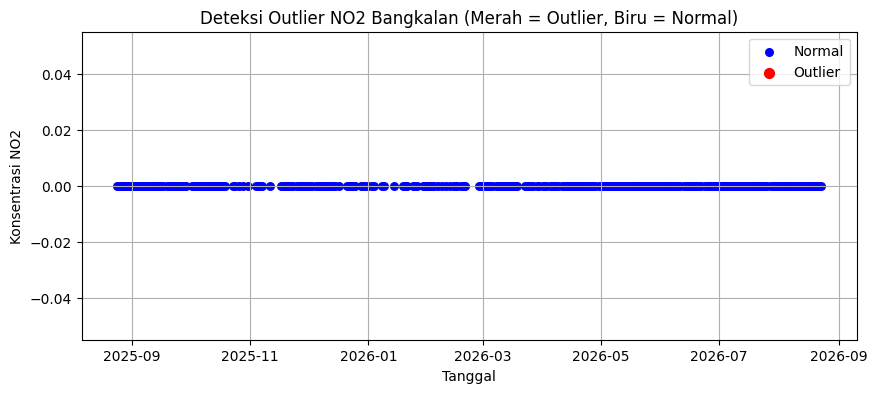

In [3]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df_clean = df.dropna(subset=["NO2"]).copy()
df_clean["date"] = pd.to_datetime(df_clean["date"])

model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["NO2"]])

normal = df_clean[df_clean["outlier"] == 1]
outliers = df_clean[df_clean["outlier"] == -1]

print(f"Jumlah outlier pada data NO2 Bangkalan : {len(outliers)}")
print(f"Jumlah data normal pada data NO2 Bangkalan : {len(normal)}")

plt.figure(figsize=(10, 4))
plt.scatter(normal["date"], normal["NO2"], color="blue", label="Normal", s=30)
plt.scatter(outliers["date"], outliers["NO2"], color="red", label="Outlier", s=50)
plt.title("Deteksi Outlier NO2 Bangkalan (Merah = Outlier, Biru = Normal)")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO2")
plt.legend()
plt.grid(True)
plt.show()

Pola kode yang sama diulang untuk `bangkalan_CO.csv`,
`bangkalan_SO2.csv`, dan `bangkalan_CH4.csv` — cukup mengganti nama file
dan nama kolom polutan.

#### c. Noise

Bagian ini akan diisi setelah pemeriksaan lebih lanjut terhadap
kemungkinan derau (noise) instrumen pada data Sentinel-5P, misalnya nilai
dengan flag kualitas rendah (`qa_value` di bawah ambang tertentu) yang
belum difilter pada tahap ekstraksi.

---

## Ringkasan

| Tahap | Status | Referensi |
|-------|--------|-----------|
| Business Understanding | Selesai — tujuan & konteks wilayah terdefinisi | Bagian 1 |
| Data Understanding — sumber & AOI | Selesai | Bagian 2.1 – 2.4 |
| Data Understanding — ekstraksi | Membutuhkan eksekusi notebook | `1-ekstraksi-data.ipynb` |
| Data Understanding — kualitas data | Membutuhkan data hasil ekstraksi | `2-analisis-bangkalan.ipynb` |

Setelah notebook ekstraksi dijalankan dan file CSV tersedia di
`../data/csv/`, seluruh sel kode pada Bagian 2.6 di atas akan otomatis
menghasilkan angka dan grafik yang sebenarnya saat halaman ini dibangun
ulang oleh Jupyter Book.

## Kesimpulan

**Business Understanding.** Kabupaten Bangkalan memiliki karakteristik
yang menjadikannya relevan untuk dipantau kualitas udaranya: posisinya
sebagai gerbang utama Jembatan Suramadu meningkatkan potensi emisi dari
sektor transportasi, sementara rencana pertumbuhan kawasan industri dan
fasilitas stockpile batu bara di pesisir utara berpotensi menambah beban
polutan seperti SO2 dan partikel debu di masa depan. Empat polutan yang
dipilih — NO2, CO, SO2, dan CH4 — mewakili sumber emisi yang berbeda
(transportasi, industri, dan aktivitas agraris), sehingga analisis ini
dapat menjadi **baseline** kualitas udara sebelum pembangunan lebih lanjut
berlangsung, sekaligus alat pemantauan tren dan deteksi anomali yang bisa
dijalankan berkala.

**Data Understanding.** Data Sentinel-5P L2 yang diakses melalui openEO
Copernicus Data Space Ecosystem terbukti dapat diambil untuk wilayah dan
rentang waktu yang ditentukan (24 Agustus 2025 – 24 Agustus 2026), dengan
catatan penting bahwa ekstraksi harus dilakukan **per polutan** karena
keterbatasan backend. Area of Interest yang didefinisikan dalam bentuk
bounding box dan polygon sudah divalidasi secara visual melalui peta
interaktif, dan mencakup titik-titik kontekstual yang relevan (akses
Suramadu, pesisir Klampis). Potensi masalah kualitas data yang perlu
diantisipasi pada tahap **Data Preparation** berikutnya adalah:
*missing values* (akibat tutupan awan/lintasan satelit yang tidak lengkap)
dan *outlier* (yang akan dideteksi dengan Isolation Forest,
`contamination=0.05`). Data dinyatakan **siap dianalisis lebih lanjut**
setelah kedua isu ini ditangani pada `2-analisis-bangkalan.ipynb`.